In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df = pd.read_csv("/media/8TB_hardisk/sangam/timeseries_forecasting/data/wonung/combined_sorted_data15/combined_sorted_data01.csv")

In [3]:
df.head()

,scenario_number,TIME,PPS,TGRCS(10),TGRCS(15),ZWV,PSGGEN(1),ZWDC2SG(1)S,MAX_CET,RCP_pump,HX,HPI,LPI,CNMT_Spray,MDAFW,Charging_pump,SAMG_1,SAMG_2,SAMG_3
0,0.0,0.0,0.736942,0.465677,0.375636,0.799655,0.701353,0.738794,0.261356,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.736942,0.465677,0.375636,0.799655,0.701353,0.738794,0.261356,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.736942,0.465677,0.375636,0.799655,0.701353,0.738794,0.261356,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,915.0,0.712488,0.465677,0.364748,0.799655,0.793979,0.674845,0.261356,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1800.0,0.715981,0.459194,0.361546,0.799655,0.792617,0.729658,0.260206,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [4]:
scenario_numbers = df['scenario_number'].unique()
scenario_numbers[:-10]

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.1487e+04, 1.1488e+04,
       1.1489e+04])

In [5]:
df.tail()

,scenario_number,TIME,PPS,TGRCS(10),TGRCS(15),ZWV,PSGGEN(1),ZWDC2SG(1)S,MAX_CET,RCP_pump,HX,HPI,LPI,CNMT_Spray,MDAFW,Charging_pump,SAMG_1,SAMG_2,SAMG_3
3191508,11499.0,255609.05,0.216988,0.393546,0.363807,0.569152,0.205635,0.651450,0.329574,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3191509,11499.0,256509.05,0.216942,0.380805,0.363619,0.562693,0.205674,0.641288,0.329574,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3191510,11499.0,257409.05,0.216884,0.380040,0.364018,0.562511,0.205626,0.649129,0.329574,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3191511,11499.0,258309.05,0.216821,0.379227,0.364215,0.563304,0.205665,0.638508,0.329574,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3191512,11499.0,259200.05,0.216765,0.378361,0.364113,0.581268,0.205683,0.635574,0.329574,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [6]:
def split_last_n_scenarios(df, n):
    """
    Splits the dataframe into two based on the last `n` scenario_numbers (sorted).
    
    Parameters:
    - df: pandas DataFrame with a 'scenario_number' column.
    - n: Integer, number of last scenario_numbers to include in the second dataframe.
    
    Returns:
    - df_excluded: DataFrame excluding the last `n` scenarios.
    - df_included: DataFrame including only the last `n` scenarios.
    """
    # Drop NaNs in scenario_number if any, just for sorting logic
    valid_scenarios = df['scenario_number'].dropna().unique()
    last_n = sorted(valid_scenarios)[-n:]

    mask = df['scenario_number'].isin(last_n)
    df_included = df[mask].copy()
    df_excluded = df[~mask].copy()
    return df_excluded, df_included

In [7]:
df_excluded, df_included = split_last_n_scenarios(df, 10)

In [8]:
df_excluded.head(20)

,scenario_number,TIME,PPS,TGRCS(10),TGRCS(15),ZWV,PSGGEN(1),ZWDC2SG(1)S,MAX_CET,RCP_pump,HX,HPI,LPI,CNMT_Spray,MDAFW,Charging_pump,SAMG_1,SAMG_2,SAMG_3
0,0.0,0.0,0.736942,0.465677,0.375636,0.799655,0.701353,0.738794,0.261356,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.736942,0.465677,0.375636,0.799655,0.701353,0.738794,0.261356,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.736942,0.465677,0.375636,0.799655,0.701353,0.738794,0.261356,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,915.0,0.712488,0.465677,0.364748,0.799655,0.793979,0.674845,0.261356,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1800.0,0.715981,0.459194,0.361546,0.799655,0.792617,0.729658,0.260206,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
5,0.0,2700.0,0.702007,0.466603,0.364108,0.799655,0.793979,0.743361,0.261586,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
6,0.0,3610.0,0.761397,0.467529,0.365389,0.799655,0.793979,0.734226,0.261816,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
7,0.0,4520.0,0.625150,0.458268,0.360265,0.799655,0.793298,0.734226,0.259746,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
8,0.0,5400.0,0.628643,0.453637,0.355782,0.799655,0.791255,0.743361,0.258596,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
9,0.0,6300.0,0.628643,0.457342,0.357704,0.799655,0.791255,0.743361,0.259286,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [9]:
df_included.head(10)

,scenario_number,TIME,PPS,TGRCS(10),TGRCS(15),ZWV,PSGGEN(1),ZWDC2SG(1)S,MAX_CET,RCP_pump,HX,HPI,LPI,CNMT_Spray,MDAFW,Charging_pump,SAMG_1,SAMG_2,SAMG_3
3188603,11490.0,0.00000,0.738359,0.465736,0.375641,0.8,0.701191,0.740979,0.261371,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3188604,11490.0,0.00000,0.738359,0.465736,0.375641,0.8,0.701191,0.740979,0.261371,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3188605,11490.0,0.00000,0.738359,0.465736,0.375641,0.8,0.701191,0.740979,0.261371,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3188606,11490.0,915.15848,0.711347,0.465336,0.365064,0.8,0.793754,0.673753,0.261258,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3188607,11490.0,1798.15850,0.714530,0.459041,0.361363,0.8,0.792843,0.730474,0.260250,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3188608,11490.0,2698.17700,0.703667,0.466814,0.364403,0.8,0.793863,0.741460,0.261539,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3188609,11490.0,3610.07230,0.761886,0.467716,0.365136,0.8,0.794273,0.736177,0.261908,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3188610,11490.0,4515.27230,0.625860,0.458131,0.360206,0.8,0.792975,0.735816,0.259767,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3188611,11490.0,5397.27230,0.629074,0.454084,0.355736,0.8,0.790932,0.744035,0.258503,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3188612,11490.0,6300.27230,0.629452,0.457159,0.357631,0.8,0.791120,0.744939,0.259246,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [10]:
df_excluded.to_csv("/media/8TB_hardisk/sangam/timeseries_forecasting/data/wonung/combined_sorted_data15/wonung_train_data_900.csv", index = False)
df_included.to_csv("/media/8TB_hardisk/sangam/timeseries_forecasting/data/wonung/combined_sorted_data15/wonung_test_data_900.csv", index = False)

In [11]:
df_excluded.describe()

,scenario_number,TIME,PPS,TGRCS(10),TGRCS(15),ZWV,PSGGEN(1),ZWDC2SG(1)S,MAX_CET,RCP_pump,HX,HPI,LPI,CNMT_Spray,MDAFW,Charging_pump,SAMG_1,SAMG_2,SAMG_3
count,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06,3.188603e+06
mean,5.517182e+03,1.285339e+05,2.988419e-01,4.912530e-01,3.949531e-01,4.875491e-01,7.068131e-01,6.747755e-01,3.126899e-01,2.257540e-02,7.511377e-01,1.036714e-01,1.097663e-01,1.295364e-02,5.793835e-01,1.103681e-01,8.109100e-02,2.429192e-01,2.296125e-01
std,3.211980e+03,7.558167e+04,1.562911e-01,1.001934e-01,6.293641e-02,2.681275e-01,1.731182e-01,1.565972e-01,9.124071e-02,1.485455e-01,4.323539e-01,3.048339e-01,3.125982e-01,1.130745e-01,4.936581e-01,3.133480e-01,2.729749e-01,4.288468e-01,4.205837e-01
min,0.000000e+00,0.000000e+00,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.745000e+03,6.297683e+04,2.066962e-01,4.483987e-01,3.597646e-01,2.005916e-01,7.344560e-01,6.912478e-01,2.606646e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.496000e+03,1.286791e+05,2.127555e-01,4.879725e-01,3.845850e-01,5.400022e-01,7.924203e-01,7.422859e-01,3.197631e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.244000e+03,1.943724e+05,3.471032e-01,5.583891e-01,4.284492e-01,8.000000e-01,7.926366e-01,7.483873e-01,3.197631e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.148900e+04,2.592000e+05,8.000000e-01,8.000000e-01,8.000000e-01,8.000000e-01,8.000000e-01,8.000000e-01,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [12]:
import matplotlib.pyplot as plt
def plot_column(col_name, df):
    plt.figure(figsize=(12, 4))
    plt.plot(df[col_name].values, label=col_name)
    plt.title(f"Time Series Plot: {col_name}")
    plt.xlabel("Timestep")
    plt.ylabel(col_name)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Index(['scenario_number', 'TIME', 'PPS', 'TGRCS(10)', 'TGRCS(15)', 'ZWV',
       'PSGGEN(1)', 'ZWDC2SG(1)S', 'MAX_CET', 'RCP_pump', 'HX', 'HPI', 'LPI',
       'CNMT_Spray', 'MDAFW', 'Charging_pump', 'SAMG_1', 'SAMG_2', 'SAMG_3'],
      dtype='object')


/tmp/ipykernel_6222/1751576535.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/sangam/anaconda3/envs/transformers_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


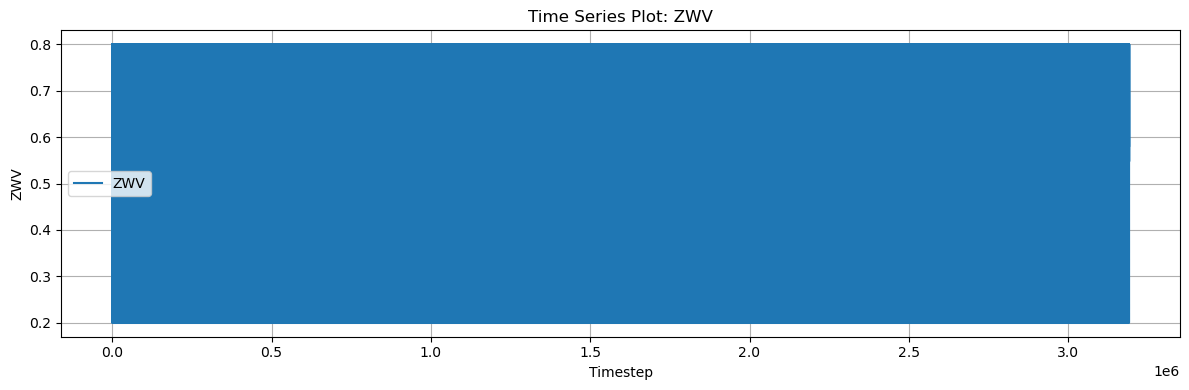

In [13]:
print(df.columns)
plot_column("ZWV", df)

In [40]:
original_df = pd.read_csv("/media/8TB_hardisk/sangam/timeseries_forecasting/raw_data/somedata.CSV")
original_df.head()

,TIME,TGRCS(15),TGRCS(10),PSGGEN(1),PPS,ZWV,MAX_CET,ZWDC2SG(1)S,T_SC
0,SECONDS,K,K,PA,PA,M,***,M,***
1,0.00E+00,6.00E+02,5.69E+02,7.38E+06,1.55E+07,6.67E+00,5.69E+02,1.18E+01,3.30E+01
2,1.00E-03,6.00E+02,5.69E+02,7.38E+06,1.55E+07,6.67E+00,5.69E+02,1.18E+01,3.30E+01
3,5.57E+00,6.04E+02,5.73E+02,7.29E+06,1.60E+07,6.67E+00,5.71E+02,1.19E+01,2.86E+01
4,9.17E+00,6.10E+02,5.70E+02,7.17E+06,1.67E+07,6.67E+00,5.72E+02,1.19E+01,2.62E+01


In [41]:
original_df.describe()

,TIME,TGRCS(15),TGRCS(10),PSGGEN(1),PPS,ZWV,MAX_CET,ZWDC2SG(1)S,T_SC
count,4401,4401,4401,4401,4401,4401,4401,4401,4401
unique,1317,409,304,320,705,245,319,1061,1912
top,1.02E+05,5.76E+02,5.75E+02,8.72E+06,1.24E+07,2.18E+00,8.04E+02,5.37E-03,1.88E-02
freq,17,147,165,2247,164,2163,3042,656,28


In [42]:
len(list(original_df.columns)), len(list(df.columns))

(9, 19)